## Architecture #3 + OG Neutrosophic Loss (Low Data Regime)

##### 1. Imports

In [1]:
import numpy as np
import pandas as pd

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.layers import ( 
    SpatialDropout1D, Embedding, Bidirectional, 
    LSTM, Dense, Dropout, 
    BatchNormalization, Input, Layer,
    GlobalAveragePooling1D, GlobalMaxPooling1D, Concatenate,
    Attention, MultiHeadAttention, LayerNormalization
)

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

2026-02-06 05:26:05.972458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770355566.329508      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770355566.429084      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
tf.keras.utils.set_random_seed(42)

##### 2. Load Dataset (20%)

In [3]:
file = r"/kaggle/input/bias-detection-dataset-processed/balanced_bias_data_parquet.parquet"
balanced_df = pd.read_parquet(file)
balanced_df = balanced_df.sample(frac=0.2, random_state=42).reset_index(drop=True)

print(balanced_df)
print("\nColumns:", balanced_df.columns)
print("\nShape:", balanced_df.shape)

        Unnamed: 0                                               text  \
0           907743  i cant breathe! just call me hott stuffy! lol....   
1          1758411  the cma is dominated by social justice warrior...   
2          2316667  one thing trump has done for the better is to ...   
3          1276711  the compensation for the 11 deaths in his fami...   
4          2242836  so to summarizennmischaracterization lie lie l...   
...            ...                                                ...   
571356     2788623  it would help establish to those that cover fo...   
571357     1195206                               is bored to tears!!!   
571358     1428898  trudeau is doing far more than harper did for ...   
571359     1273210  self admitted sexual predator? you mean he was...   
571360     1399599               wheres cahinxman when you need her?!   

                                             biased_words  bias  sentiment  \
0                                            

##### 3. Tokenisation & Padding

In [4]:
MAX_VOCAB = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(balanced_df['text'])

X = tokenizer.texts_to_sequences(balanced_df['text'])
X = pad_sequences(X, maxlen=MAX_LEN, padding='post', truncating='post')
print(X.shape)

(571361, 100)


##### 4. Train-Test Split

In [5]:
y = balanced_df[['bias', 'sentiment', 'toxic']]
print(y)
print(y.shape)

        bias  sentiment  toxic
0          1          2      1
1          2          2      0
2          0          2      1
3          0          0      0
4          2          1      1
...      ...        ...    ...
571356     0          1      0
571357     2          0      1
571358     1          1      1
571359     0          0      0
571360     1          1      1

[571361 rows x 3 columns]
(571361, 3)


In [6]:
# split for training, testing and validation as 80%-10%-10%.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

In [7]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_valid:", X_valid.shape)

y_train_bias = y_train["bias"].to_numpy()
y_train_sentiment = y_train["sentiment"].to_numpy()
y_train_toxic = y_train["toxic"].to_numpy()

print("y_train_bias:", y_train_bias.shape)
print("y_train_sentiment:", y_train_sentiment.shape)
print("y_train_toxic:", y_train_toxic.shape)

y_test_bias = y_test["bias"].to_numpy()
y_test_sentiment = y_test["sentiment"].to_numpy()
y_test_toxic = y_test["toxic"].to_numpy()

print("y_test_bias:", y_test_bias.shape)
print("y_test_sentiment:", y_test_sentiment.shape)
print("y_test_toxic:", y_test_toxic.shape)

y_valid_bias = y_valid["bias"].to_numpy()
y_valid_sentiment = y_valid["sentiment"].to_numpy()
y_valid_toxic = y_valid["toxic"].to_numpy()

print("y_valid_bias:", y_valid_bias.shape)
print("y_valid_sentiment:", y_valid_sentiment.shape)
print("y_valid_toxic:", y_valid_toxic.shape)

X_train: (399952, 100)
X_test: (85704, 100)
X_valid: (85705, 100)
y_train_bias: (399952,)
y_train_sentiment: (399952,)
y_train_toxic: (399952,)
y_test_bias: (85704,)
y_test_sentiment: (85704,)
y_test_toxic: (85704,)
y_valid_bias: (85705,)
y_valid_sentiment: (85705,)
y_valid_toxic: (85705,)


In [11]:
y_train_bias_oh = to_categorical(y_train_bias, num_classes=3)
y_valid_bias_oh = to_categorical(y_valid_bias, num_classes=3)
y_test_bias_oh = to_categorical(y_test_bias, num_classes=3)

y_train_sentiment_oh = to_categorical(y_train_sentiment, num_classes=3)
y_valid_sentiment_oh = to_categorical(y_valid_sentiment, num_classes=3)
y_test_sentiment_oh = to_categorical(y_test_sentiment, num_classes=3)

y_train_toxic_oh = to_categorical(y_train_toxic, num_classes=2)
y_valid_toxic_oh = to_categorical(y_valid_toxic, num_classes=2)
y_test_toxic_oh = to_categorical(y_test_toxic, num_classes=2)

##### 5. Neutrosophic Loss Function

In [12]:
def neutrosophic_loss(alpha, beta, gamma):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_sigmoid = tf.clip_by_value(tf.nn.sigmoid(y_pred), 1e-7, 1-1e-7)

        truth = -y_true * tf.math.log(y_sigmoid)
        falsity = -(1 - y_true) * tf.math.log(1 - y_sigmoid)
        indeterminacy = 1.0 - tf.abs(y_sigmoid - 0.5) * 2.0

        neutro_loss = alpha * truth + beta * falsity + gamma * indeterminacy
        return tf.reduce_mean(neutro_loss)
    return loss_fn

##### 6. Model Architecture

In [13]:
def build_model(alpha, beta, gamma):
    MAX_VOCAB = 10000
    input_layer = Input(shape=(100,))
    
    x = Embedding(MAX_VOCAB, 512, trainable=True)(input_layer)
    
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(x)
    x = LayerNormalization()(x)
    
    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3))(x)
    x = LayerNormalization()(x)
    
    # Multi-head attention
    attn = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    
    # Dual pooling
    avg_pool = GlobalAveragePooling1D()(attn)
    max_pool = GlobalMaxPooling1D()(attn)
    x = Concatenate()([avg_pool, max_pool])
    
    x = Dense(256, activation="gelu")(x)
    x = Dropout(0.4)(x)
    
    x = Dense(128, activation="gelu", kernel_regularizer=l2(1e-4))(x)

    neutro = Dense(128, activation="tanh", name="neutro_latent")(x)
    
    # Output heads
    output_b = Dense(3, activation='linear', name='output_b')(neutro)
    output_s = Dense(3, activation='linear', name='output_s')(neutro)
    output_t = Dense(2, activation='linear', name='output_t')(neutro)
    
    model = Model(inputs=input_layer, outputs=[output_b, output_s, output_t])

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-3,
        decay_steps=10000,
        decay_rate=0.9
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss={
            "output_b": neutrosophic_loss(alpha, beta, gamma),
            "output_s": neutrosophic_loss(alpha, beta, gamma),
            "output_t": neutrosophic_loss(alpha, beta, gamma),
        },
        metrics={
            "output_b": tf.keras.metrics.CategoricalAccuracy(name="acc"),
            "output_s": tf.keras.metrics.CategoricalAccuracy(name="acc"),
            "output_t": tf.keras.metrics.CategoricalAccuracy(name="acc")
        }
    )
    return model

##### 6. Model Training

In [15]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model = build_model(0.9391, 0.6620, 0.1349)

history = model.fit(
    X_train,
    {
        "output_b": y_train_bias_oh,
        "output_s": y_train_sentiment_oh,
        "output_t": y_train_toxic_oh
    },
    validation_data=(
        X_valid,
        {
            "output_b": y_valid_bias_oh,
            "output_s": y_valid_sentiment_oh,
            "output_t": y_valid_toxic_oh
        }
    ),
    epochs=10,
    batch_size=512,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 167ms/step - loss: 1.3198 - output_b_acc: 0.6891 - output_b_loss: 0.3878 - output_s_acc: 0.6490 - output_s_loss: 0.4279 - output_t_acc: 0.7118 - output_t_loss: 0.4898 - val_loss: 0.7856 - val_output_b_acc: 0.8376 - val_output_b_loss: 0.2361 - val_output_s_acc: 0.8687 - val_output_s_loss: 0.2055 - val_output_t_acc: 0.8294 - val_output_t_loss: 0.3341
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 129s 165ms/step - loss: 0.7682 - output_b_acc: 0.8405 - output_b_loss: 0.2346 - output_s_acc: 0.8793 - output_s_loss: 0.1936 - output_t_acc: 0.8311 - output_t_loss: 0.3314 - val_loss: 0.7265 - val_output_b_acc: 0.8503 - val_output_b_loss: 0.2210 - val_output_s_acc: 0.8904 - val_output_s_loss: 0.1782 - val_output_t_acc: 0.8368 - val_output_t_loss: 0.3203
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 129s 165ms/step - loss: 0.6942 - output_b_acc: 0.8561 - output_b_loss: 0.2144 - output_s_acc: 0.8985 - output_s_loss: 0.1677 - output_t_acc: 0.8458 - output_t_loss: 0.3

##### 7. Model Evaluation

670/670 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step
====================== Bias Task ======================
Accuracy: 0.8569
                 precision    recall  f1-score   support

  Highly Biased       0.86      0.90      0.88     24535
        Neutral       0.87      0.89      0.88     26737
Slightly Biased       0.84      0.80      0.82     34432

       accuracy                           0.86     85704
      macro avg       0.86      0.86      0.86     85704
   weighted avg       0.86      0.86      0.86     85704


==================== Sentiment Task ====================
Accuracy: 0.9020
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87     18822
     Neutral       0.92      0.88      0.90     29552
    Positive       0.90      0.94      0.92     37330

    accuracy                           0.90     85704
   macro avg       0.90      0.89      0.90     85704
weighted avg       0.90      0.90      0.90     85704


====================== To

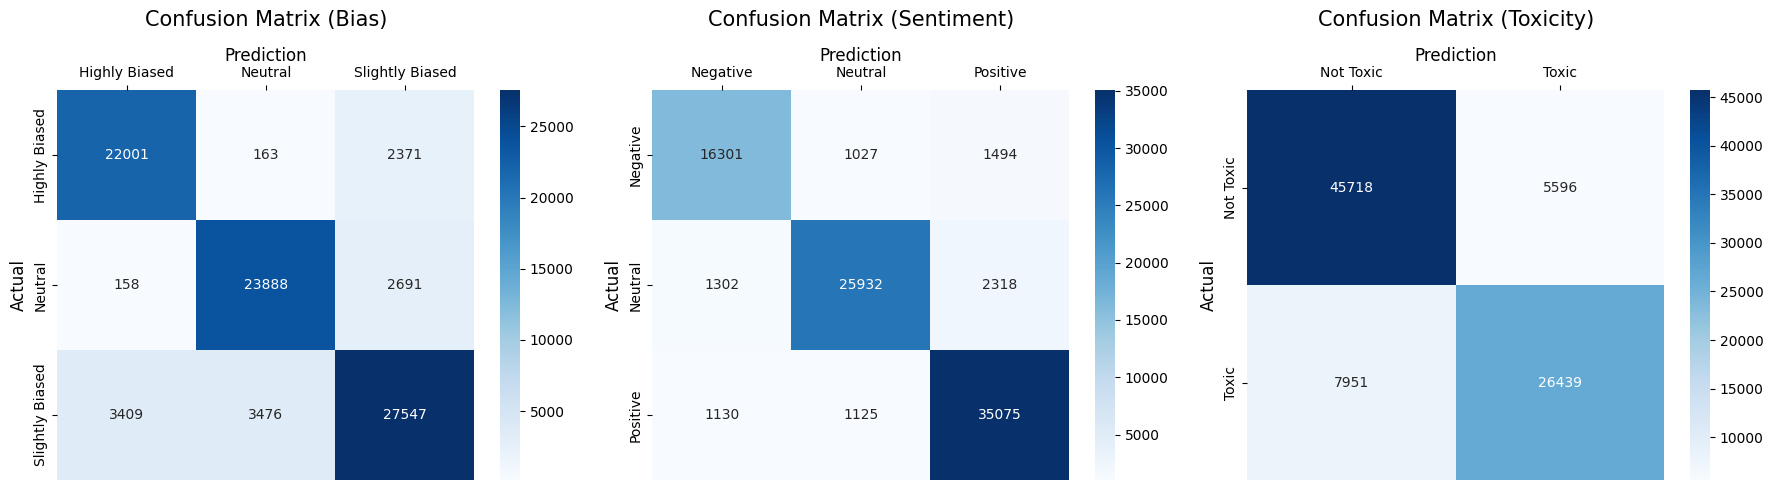

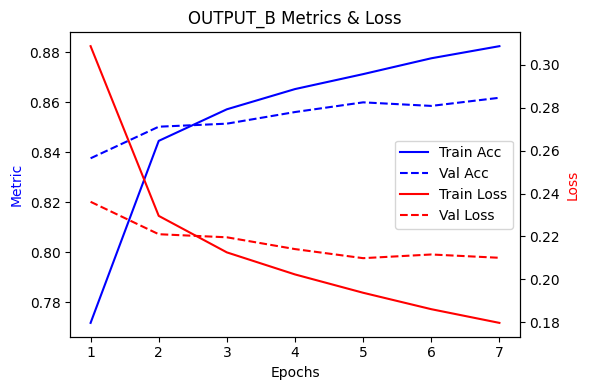

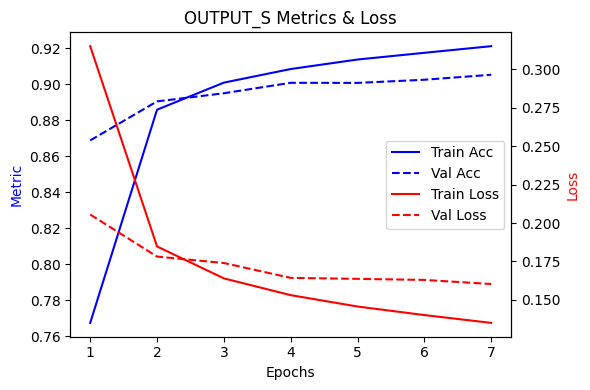

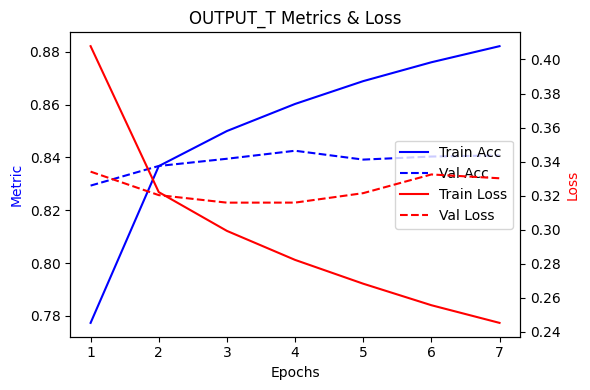


--------------------------------------------------------------------------



In [16]:
y_pred_probs = model.predict(X_test, batch_size=128)

y_pred_bias = np.argmax(y_pred_probs[0], axis=1)
y_pred_sentiment = np.argmax(y_pred_probs[1], axis=1)
y_pred_toxic = np.argmax(y_pred_probs[2], axis=1)

y_true_bias = np.argmax(y_test_bias_oh, axis=1)
y_true_sentiment = np.argmax(y_test_sentiment_oh, axis=1)
y_true_toxic = np.argmax(y_test_toxic_oh, axis=1)

bias_labels = ['Highly Biased', 'Neutral', 'Slightly Biased']
sentiment_labels = ['Negative', 'Neutral', 'Positive']
toxicity_labels = ['Not Toxic', 'Toxic']

print("====================== Bias Task ======================")
print(f"Accuracy: {accuracy_score(y_true_bias, y_pred_bias):.4f}")
print(classification_report(y_true_bias, y_pred_bias, target_names=bias_labels))

print("\n==================== Sentiment Task ====================")
print(f"Accuracy: {accuracy_score(y_true_sentiment, y_pred_sentiment):.4f}")
print(classification_report(y_true_sentiment, y_pred_sentiment, target_names=sentiment_labels))

print("\n====================== Toxic Task ======================")
print(f"Accuracy: {accuracy_score(y_true_toxic, y_pred_toxic):.4f}")
print(classification_report(y_true_toxic, y_pred_toxic, target_names=toxicity_labels))

def plot_cm(y_true, y_pred, labels, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', xticklabels=labels, yticklabels=labels, cmap="Blues", ax=ax)
    ax.set_title(title, fontsize=15, pad=15)
    ax.set_xlabel('Prediction', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_cm(y_true_bias, y_pred_bias, bias_labels, 'Confusion Matrix (Bias)', axes[0])
plot_cm(y_true_sentiment, y_pred_sentiment, sentiment_labels, 'Confusion Matrix (Sentiment)', axes[1])
plot_cm(y_true_toxic, y_pred_toxic, toxicity_labels, 'Confusion Matrix (Toxicity)', axes[2])

plt.tight_layout()
plt.show()

def plot_history_combined(history, outputs, metrics=None):
    if metrics is None:
        metrics = []
        for key in history.history.keys():
            for output in outputs:
                if key.startswith(output) and not key.endswith("loss"):
                    metric_name = key[len(output)+1:]  # remove output_
                    if metric_name not in metrics:
                        metrics.append(metric_name)
    
    epochs = range(1, len(history.history[f"{outputs[0]}_loss"]) + 1)

    for output in outputs:
        fig, ax1 = plt.subplots(figsize=(6, 4))

        ax2 = ax1.twinx()
        for metric in metrics:
            train_metric = history.history.get(f"{output}_{metric}")
            val_metric = history.history.get(f"val_{output}_{metric}")
            if train_metric and val_metric:
                ax1.plot(epochs, train_metric, "b-", label=f"Train {metric.title()}")
                ax1.plot(epochs, val_metric, "b--", label=f"Val {metric.title()}")

        train_loss = history.history.get(f"{output}_loss")
        val_loss = history.history.get(f"val_{output}_loss")
        if train_loss and val_loss:
            ax2.plot(epochs, train_loss, "r-", label="Train Loss")
            ax2.plot(epochs, val_loss, "r--", label="Val Loss")

        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("Metric", color="b")
        ax2.set_ylabel("Loss", color="r")
        ax1.set_title(f"{output.upper()} Metrics & Loss")

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

        plt.tight_layout()
        plt.show()
    
outputs = ["output_b", "output_s", "output_t"]
plot_history_combined(history, outputs)

print("\n--------------------------------------------------------------------------\n")